<a href="https://colab.research.google.com/github/Tusharshinde94/Tusharshinde94/blob/main/Book_user_Rating_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud,STOPWORDS
import string
import re

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [39]:
Users = pd.read_csv('Users.csv', encoding='latin1', on_bad_lines='skip')
Books = pd.read_csv('Books.csv', encoding='latin1', on_bad_lines='skip')
Ratings = pd.read_csv('Ratings.csv', encoding='latin1', on_bad_lines='skip')


# skip the problematic line
#Users = pd.read_csv('Users.csv', encoding='latin1', delimiter=';', on_bad_lines='skip')  # Try a different delimiter like ';' if ',' is not the correct one

In [40]:
Users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [41]:
book_ratings = pd.merge(Ratings, Books, on='ISBN')
all_data = pd.merge(book_ratings, Users, on='User-ID')
all_data.head() #Execute the code yourself to see the output

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,2313,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"cincinnati, ohio, usa",23.0
2,2313,0812533550,9.0,Ender's Game (Ender Wiggins Saga (Paperback)),Orson Scott Card,1986,Tor Books,http://images.amazon.com/images/P/0812533550.0...,http://images.amazon.com/images/P/0812533550.0...,http://images.amazon.com/images/P/0812533550.0...,"cincinnati, ohio, usa",23.0
3,2313,0679745580,8.0,In Cold Blood (Vintage International),TRUMAN CAPOTE,1994,Vintage,http://images.amazon.com/images/P/0679745580.0...,http://images.amazon.com/images/P/0679745580.0...,http://images.amazon.com/images/P/0679745580.0...,"cincinnati, ohio, usa",23.0
4,2313,0060173289,9.0,Divine Secrets of the Ya-Ya Sisterhood : A Novel,Rebecca Wells,1996,HarperCollins,http://images.amazon.com/images/P/0060173289.0...,http://images.amazon.com/images/P/0060173289.0...,http://images.amazon.com/images/P/0060173289.0...,"cincinnati, ohio, usa",23.0


In [42]:
# Data Cleaning

In [43]:
# prompt: Data Cleaning

import pandas as pd
# Check for missing values
print(all_data.isnull().sum())

# Remove rows with missing values in crucial columns (e.g., Book-Title, Book-Author)
all_data.dropna(subset=['Book-Title', 'Book-Author'], inplace=True)

# Fill missing values in other columns with appropriate strategies (e.g., mean, median, mode)
# Example: Fill missing 'Age' values with the mean age
all_data['Age'].fillna(all_data['Age'].mean(), inplace=True)

# Check for duplicate rows
print(all_data.duplicated().sum())

# Remove duplicate rows if any
all_data.drop_duplicates(inplace=True)

# Convert data types if needed
# Example: Convert 'Year-Of-Publication' to integer
all_data['Year-Of-Publication'] = pd.to_numeric(all_data['Year-Of-Publication'], errors='coerce')

# Handle inconsistent data (e.g., different spellings of author names)
# This might require manual review and correction

# Remove irrelevant columns if needed
# Example: If 'Image-URL-S' is not relevant, remove it
#all_data.drop('Image-URL-S', axis=1, inplace=True)

# You can add more specific data cleaning steps based on your analysis needs

# After cleaning, you can check the cleaned dataset again
print(all_data.isnull().sum())
all_data.head()


User-ID                     0
ISBN                        0
Book-Rating                 0
Book-Title                  0
Book-Author                 2
Year-Of-Publication         0
Publisher                   2
Image-URL-S                 0
Image-URL-M                 0
Image-URL-L                 4
Location                    0
Age                    277811
dtype: int64
0
User-ID                0
ISBN                   0
Book-Rating            0
Book-Title             0
Book-Author            0
Year-Of-Publication    4
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            4
Location               0
Age                    0
dtype: int64


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",37.398759
1,2313,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"cincinnati, ohio, usa",23.000000
2,2313,0812533550,9.0,Ender's Game (Ender Wiggins Saga (Paperback)),Orson Scott Card,1986.0,Tor Books,http://images.amazon.com/images/P/0812533550.0...,http://images.amazon.com/images/P/0812533550.0...,http://images.amazon.com/images/P/0812533550.0...,"cincinnati, ohio, usa",23.000000
3,2313,0679745580,8.0,In Cold Blood (Vintage International),TRUMAN CAPOTE,1994.0,Vintage,http://images.amazon.com/images/P/0679745580.0...,http://images.amazon.com/images/P/0679745580.0...,http://images.amazon.com/images/P/0679745580.0...,"cincinnati, ohio, usa",23.000000
4,2313,0060173289,9.0,Divine Secrets of the Ya-Ya Sisterhood : A Novel,Rebecca Wells,1996.0,HarperCollins,http://images.amazon.com/images/P/0060173289.0...,http://images.amazon.com/images/P/0060173289.0...,http://images.amazon.com/images/P/0060173289.0...,"cincinnati, ohio, usa",23.000000


In [44]:


print(all_data.isnull().sum())


User-ID                0
ISBN                   0
Book-Rating            0
Book-Title             0
Book-Author            0
Year-Of-Publication    4
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            4
Location               0
Age                    0
dtype: int64


In [45]:

# Check if any null values remain in 'Age' after filling with the mean
if all_data['Age'].isnull().any():
  print("Null values still exist in 'Age' column.")
else:
  print("All null values in 'Age' have been filled with the mean.")


# Iterate through all columns and check if any null values still exist.
# If so, print a message indicating which column has null values.
for column in all_data.columns:
  if all_data[column].isnull().any():
      print(f"Null values still exist in '{column}' column.")


All null values in 'Age' have been filled with the mean.
Null values still exist in 'Year-Of-Publication' column.
Null values still exist in 'Publisher' column.
Null values still exist in 'Image-URL-L' column.


In [46]:
#  We can observe from above that some author names are mixed up in year data like 'DK Publishing Inc' and 'Gallimard'
# Checking the rows having 'DK Publishing Inc' as yearOfPublication using

# Check rows where 'Year-Of-Publication' is 'DK Publishing Inc'
dk_publishing_rows = all_data[all_data['Year-Of-Publication'] == 'DK Publishing Inc']

# Print those rows
print(dk_publishing_rows)


Empty DataFrame
Columns: [User-ID, ISBN, Book-Rating, Book-Title, Book-Author, Year-Of-Publication, Publisher, Image-URL-S, Image-URL-M, Image-URL-L, Location, Age]
Index: []


In [47]:
#There are Two Books with wrong year entries, Hence we will correct them below
# And also check if any entries are wrong and correct them

import pandas as pd
# Correct the Year-Of-Publication for the two books with wrong entries
all_data.loc[all_data['Book-Title'] == 'DK Readers: Creating the X-Men', 'Year-Of-Publication'] = 2000
all_data.loc[all_data['Book-Title'] == 'DK Readers: Creating the X-Men', 'Book-Author'] = 'Michael Teitelbaum'
all_data.loc[all_data['Book-Title'] == 'The Murder of Roger Ackroyd', 'Year-Of-Publication'] = 1926

# Check for other potential errors in Year-Of-Publication
# For example, if years are significantly outside a reasonable range (e.g., very old or far in the future)
# You can define a reasonable range (e.g., 1800-2023) and filter entries outside it.
all_data['Year-Of-Publication'] = pd.to_numeric(all_data['Year-Of-Publication'], errors='coerce')
all_data = all_data[all_data['Year-Of-Publication'].between(1800, 2023)]

# Check for other potential errors in the dataset

# You can add further checks and corrections based on your data exploration and analysis

# Example: You might check for unrealistic age values, or incorrect ISBN formats
# Print the updated info after corrections
print(all_data.info())


<class 'pandas.core.frame.DataFrame'>
Index: 1016940 entries, 0 to 1031008
Data columns (total 12 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   User-ID              1016940 non-null  int64  
 1   ISBN                 1016940 non-null  object 
 2   Book-Rating          1016940 non-null  float64
 3   Book-Title           1016940 non-null  object 
 4   Book-Author          1016940 non-null  object 
 5   Year-Of-Publication  1016940 non-null  float64
 6   Publisher            1016938 non-null  object 
 7   Image-URL-S          1016940 non-null  object 
 8   Image-URL-M          1016940 non-null  object 
 9   Image-URL-L          1016940 non-null  object 
 10  Location             1016940 non-null  object 
 11  Age                  1016940 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 100.9+ MB
None


In [48]:
# prompt: Storing Image URLs in different DataFrame because we don't need them now

# Check if the columns exist before trying to access them
if 'Image-URL-M' in all_data.columns and 'Image-URL-L' in all_data.columns:
  image_urls = all_data[['Image-URL-M', 'Image-URL-L']]
  all_data = all_data.drop(['Image-URL-M', 'Image-URL-L'], axis=1)
else:
  print("Error: 'Image-URL-M' or 'Image-URL-L' columns not found in the DataFrame.")

In [49]:
# check all data set


print(all_data)


         User-ID        ISBN  Book-Rating  \
0         276725  034545104X          0.0   
1           2313  034545104X          5.0   
2           2313  0812533550          9.0   
3           2313  0679745580          8.0   
4           2313  0060173289          9.0   
...          ...         ...          ...   
1031004   276442  2862749796          7.0   
1031005   276618  3788097000          5.0   
1031006   276647  0553571001          0.0   
1031007   276647  0689822294         10.0   
1031008   276660  0583307841          8.0   

                                                Book-Title  \
0                                     Flesh Tones: A Novel   
1                                     Flesh Tones: A Novel   
2            Ender's Game (Ender Wiggins Saga (Paperback))   
3                    In Cold Blood (Vintage International)   
4         Divine Secrets of the Ya-Ya Sisterhood : A Novel   
...                                                    ...   
1031004                  

In [50]:
book_ratings = pd.merge(Ratings, Books, on='ISBN')
all_data = pd.merge(book_ratings, Users, on='User-ID')
all_data.head() #Execute the code yourself to see the output

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,2313,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"cincinnati, ohio, usa",23.0
2,2313,0812533550,9.0,Ender's Game (Ender Wiggins Saga (Paperback)),Orson Scott Card,1986,Tor Books,http://images.amazon.com/images/P/0812533550.0...,http://images.amazon.com/images/P/0812533550.0...,http://images.amazon.com/images/P/0812533550.0...,"cincinnati, ohio, usa",23.0
3,2313,0679745580,8.0,In Cold Blood (Vintage International),TRUMAN CAPOTE,1994,Vintage,http://images.amazon.com/images/P/0679745580.0...,http://images.amazon.com/images/P/0679745580.0...,http://images.amazon.com/images/P/0679745580.0...,"cincinnati, ohio, usa",23.0
4,2313,0060173289,9.0,Divine Secrets of the Ya-Ya Sisterhood : A Novel,Rebecca Wells,1996,HarperCollins,http://images.amazon.com/images/P/0060173289.0...,http://images.amazon.com/images/P/0060173289.0...,http://images.amazon.com/images/P/0060173289.0...,"cincinnati, ohio, usa",23.0


In [51]:
book_ratings.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,2313,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
2,6543,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
3,8680,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
4,10314,034545104X,9.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...


In [52]:
# checking null values and blank and data correcting in book_ratings data set

import pandas as pd
# Check for missing values
print(book_ratings.isnull().sum())

# Remove rows with missing values in crucial columns (e.g., Book-Title, Book-Author)
book_ratings.dropna(subset=['Book-Title', 'Book-Author'], inplace=True)

# Fill missing values in other columns with appropriate strategies (e.g., mean, median, mode)
# Example: Fill missing 'Year-Of-Publication' values with the mode year
book_ratings['Year-Of-Publication'].fillna(book_ratings['Year-Of-Publication'].mode()[0], inplace=True)

# Check for duplicate rows
print(book_ratings.duplicated().sum())

# Remove duplicate rows if any
book_ratings.drop_duplicates(inplace=True)

# Convert data types if needed
# Example: Convert 'Year-Of-Publication' to integer
book_ratings['Year-Of-Publication'] = pd.to_numeric(book_ratings['Year-Of-Publication'], errors='coerce')


#  We can observe from above that some author names are mixed up in year data like 'DK Publishing Inc' and 'Gallimard'
# Checking the rows having 'DK Publishing Inc' as yearOfPublication using

# Check rows where 'Year-Of-Publication' is 'DK Publishing Inc'
dk_publishing_rows = book_ratings[book_ratings['Year-Of-Publication'] == 'DK Publishing Inc']

# Print those rows
print(dk_publishing_rows)

#There are Two Books with wrong year entries, Hence we will correct them below
# And also check if any entries are wrong and correct them

# Correct the Year-Of-Publication for the two books with wrong entries
book_ratings.loc[book_ratings['Book-Title'] == 'DK Readers: Creating the X-Men', 'Year-Of-Publication'] = 2000
book_ratings.loc[book_ratings['Book-Title'] == 'DK Readers: Creating the X-Men', 'Book-Author'] = 'Michael Teitelbaum'
book_ratings.loc[book_ratings['Book-Title'] == 'The Murder of Roger Ackroyd', 'Year-Of-Publication'] = 1926

# Check for other potential errors in Year-Of-Publication
# For example, if years are significantly outside a reasonable range (e.g., very old or far in the future)
# You can define a reasonable range (e.g., 1800-2023) and filter entries outside it.
book_ratings['Year-Of-Publication'] = pd.to_numeric(book_ratings['Year-Of-Publication'], errors='coerce')
book_ratings = book_ratings[book_ratings['Year-Of-Publication'].between(1800, 2023)]

# Check for other potential errors in the dataset

# You can add further checks and corrections based on your data exploration and analysis

# Example: You might check for unrealistic age values, or incorrect ISBN formats
# Print the updated info after corrections
print(book_ratings.info())

# Check if the columns exist before trying to access them
if 'Image-URL-M' in book_ratings.columns and 'Image-URL-L' in book_ratings.columns:
  image_urls = book_ratings[['Image-URL-M', 'Image-URL-L']]
  book_ratings = book_ratings.drop(['Image-URL-M', 'Image-URL-L'], axis=1)
else:
  print("Error: 'Image-URL-M' or 'Image-URL-L' columns not found in the DataFrame.")

print(book_ratings)


User-ID                0
ISBN                   0
Book-Rating            0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            4
dtype: int64
0
Empty DataFrame
Columns: [User-ID, ISBN, Book-Rating, Book-Title, Book-Author, Year-Of-Publication, Publisher, Image-URL-S, Image-URL-M, Image-URL-L]
Index: []
<class 'pandas.core.frame.DataFrame'>
Index: 1017065 entries, 0 to 1031135
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   User-ID              1017065 non-null  int64  
 1   ISBN                 1017065 non-null  object 
 2   Book-Rating          1017065 non-null  float64
 3   Book-Title           1017065 non-null  object 
 4   Book-Author          1017065 non-null  object 
 5   Year-Of-Publication  1017065 non-null  float64
 6   Publisher            1017063 non-null  object 

In [53]:
book_ratings.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S
0,276725,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
1,2313,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
2,6543,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
3,8680,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
4,10314,034545104X,9.0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...


In [54]:
# prompt: In year of publication i can see .0 in each values correct them to numbers

# Assuming 'Year-Of-Publication' is a column in your DataFrame
book_ratings['Year-Of-Publication'] = book_ratings['Year-Of-Publication'].astype(int)


In [55]:
book_ratings.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S
0,276725,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
1,2313,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
2,6543,034545104X,0.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
3,8680,034545104X,5.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
4,10314,034545104X,9.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...


In [56]:


# Check for duplicate rows in the 'book_ratings' DataFrame
duplicate_rows = book_ratings[book_ratings.duplicated()]

# Print the number of duplicate rows
print("Number of duplicate rows:", len(duplicate_rows))

# If you want to see the actual duplicate rows, you can print them
print("Duplicate rows:")
print(duplicate_rows)


Number of duplicate rows: 0
Duplicate rows:
Empty DataFrame
Columns: [User-ID, ISBN, Book-Rating, Book-Title, Book-Author, Year-Of-Publication, Publisher, Image-URL-S]
Index: []


In [57]:
# prompt: Convert year of publication to number

import pandas as pd
# Assuming 'Year-Of-Publication' is a column in your DataFrame
book_ratings['Year-Of-Publication'] = pd.to_numeric(book_ratings['Year-Of-Publication'], errors='coerce')


In [58]:
# prompt: check data type

print(all_data.dtypes)


User-ID                  int64
ISBN                    object
Book-Rating            float64
Book-Title              object
Book-Author             object
Year-Of-Publication     object
Publisher               object
Image-URL-S             object
Image-URL-M             object
Image-URL-L             object
Location                object
Age                    float64
dtype: object


In [59]:
# prompt: Year-Of-Publication check data type and convert it from object to numeric

import pandas as pd
# Check the data type of 'Year-Of-Publication'
print(all_data['Year-Of-Publication'].dtype)

# Convert 'Year-Of-Publication' to numeric, handling potential errors
all_data['Year-Of-Publication'] = pd.to_numeric(all_data['Year-Of-Publication'], errors='coerce')

# Check the data type again to confirm the conversion
print(all_data['Year-Of-Publication'].dtype)


object
float64


In [60]:
# Visualization of the Data Set (Books/User/Rating)


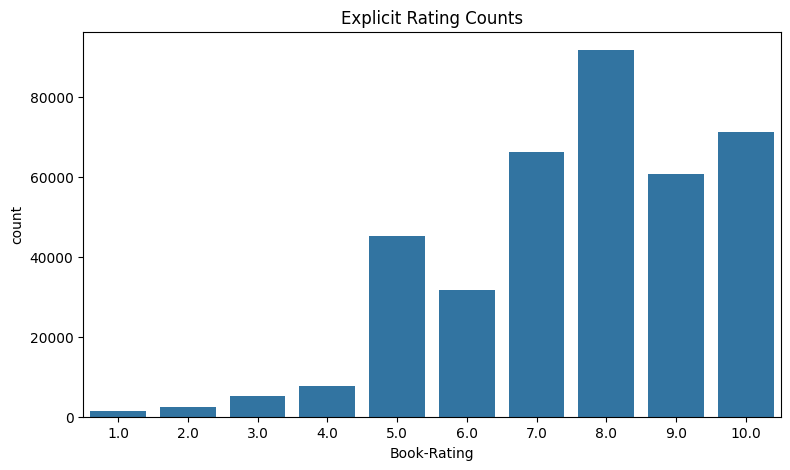

In [61]:
# prompt: plt.figure(figsize=(9, 5))
# plt.title('Explicit Rating Counts')
# sns.countplot(x = 'Book-Rating', data = rating_explicit);

import matplotlib.pyplot as plt
rating_explicit = all_data[all_data['Book-Rating'] != 0]
plt.figure(figsize=(9, 5))
plt.title('Explicit Rating Counts')
sns.countplot(x = 'Book-Rating', data = rating_explicit);


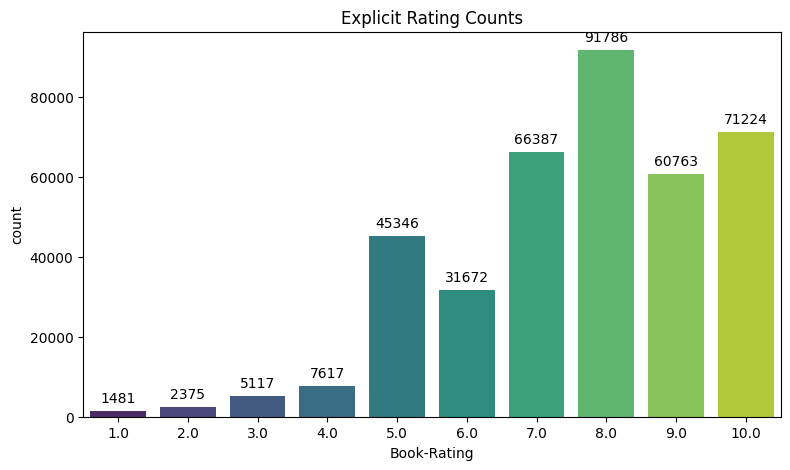

In [62]:
# prompt: need colorful chart for the above with data label

import matplotlib.pyplot as plt
import seaborn as sns

rating_explicit = all_data[all_data['Book-Rating'] != 0]
plt.figure(figsize=(9, 5))
plt.title('Explicit Rating Counts')
ax = sns.countplot(x='Book-Rating', data=rating_explicit, palette='viridis')

# Add data labels to the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()


In [63]:


# Observations from the "Explicit Rating Counts" chart:

# 1. Rating Distribution: The chart shows the distribution of explicit book ratings (ratings other than 0).
# 2. Majority of Ratings are Positive: The majority of ratings fall within the 8-10 range, indicating that a significant portion of users gave positive ratings to the books they read.
# 3. Fewer Ratings in the Lower Range: There are fewer ratings in the 1-4 range, suggesting that users are less inclined to give lower ratings.
# 4. Peak Rating: The most frequent rating seems to be 8, which means that the majority of users tend to give a rating of 8 for books.

# These observations provide insights into the overall user satisfaction with the books in the dataset.
# It appears that users generally have a positive perception of the books, as indicated by the higher frequency of ratings in the upper range.


In [64]:
# prompt: Convert the rating column to number it should be not .0

import pandas as pd
# Check the data type of the 'Book-Rating' column
print(all_data['Book-Rating'].dtype)

# If it's not already numeric, convert it to numeric, handling errors
all_data['Book-Rating'] = pd.to_numeric(all_data['Book-Rating'], errors='coerce')

# Convert to integer type
all_data['Book-Rating'] = all_data['Book-Rating'].astype(int)

# Verify the change
print(all_data['Book-Rating'].dtype)
print(all_data['Book-Rating'].unique())


float64
int64
[ 0  5  9  8  7  6 10  3  4  2  1]


In [65]:
# prompt: Make Heading as Data Exploration

print("## Data Exploration")


## Data Exploration


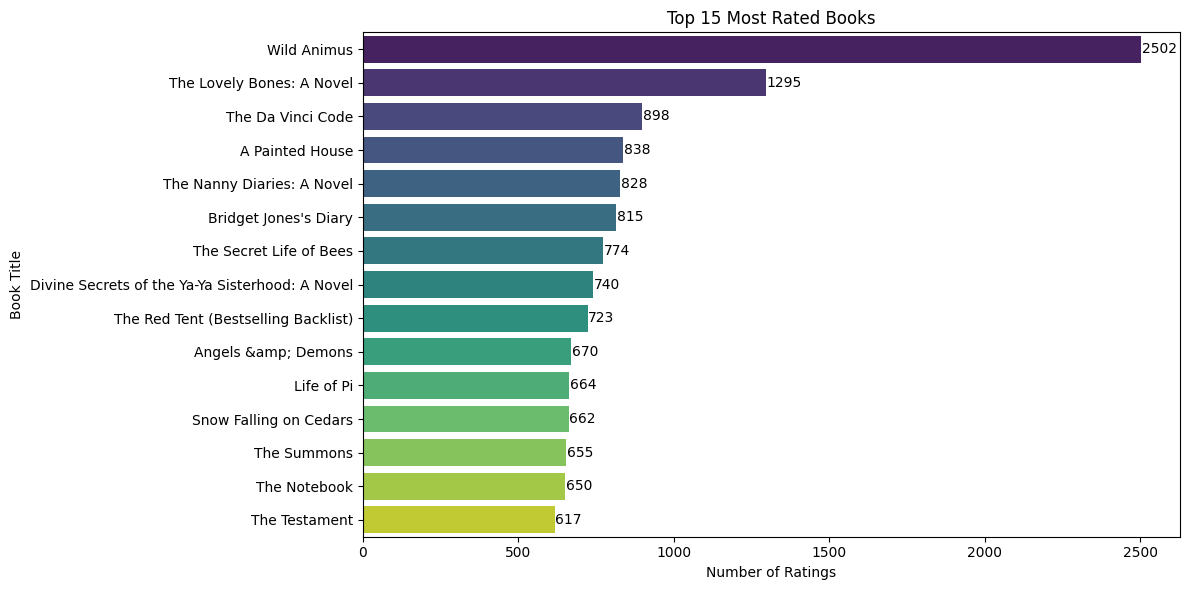

In [66]:
# prompt: Plot the bar graph for top 15 books with data label and also give oberservation in next cell

import matplotlib.pyplot as plt
top_15_books = all_data.groupby('Book-Title')['Book-Rating'].count().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_15_books.values, y=top_15_books.index, palette='viridis')
plt.title('Top 15 Most Rated Books')
plt.xlabel('Number of Ratings')
plt.ylabel('Book Title')

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 2, p.get_y() + p.get_height() / 2, f'{int(width)}',
             ha='left', va='center')

plt.tight_layout()
plt.show()


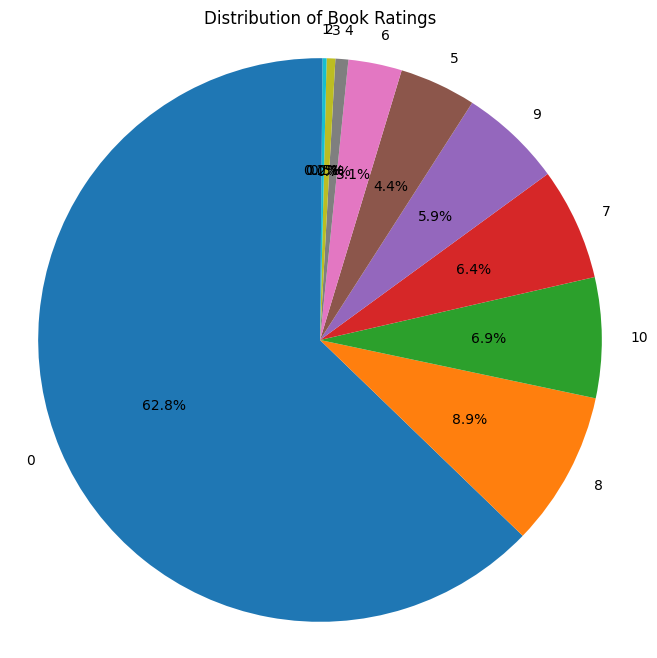

In [67]:


import matplotlib.pyplot as plt

# Assuming 'Book-Rating' is a column in your DataFrame 'all_data'
rating_counts = all_data['Book-Rating'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Book Ratings')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


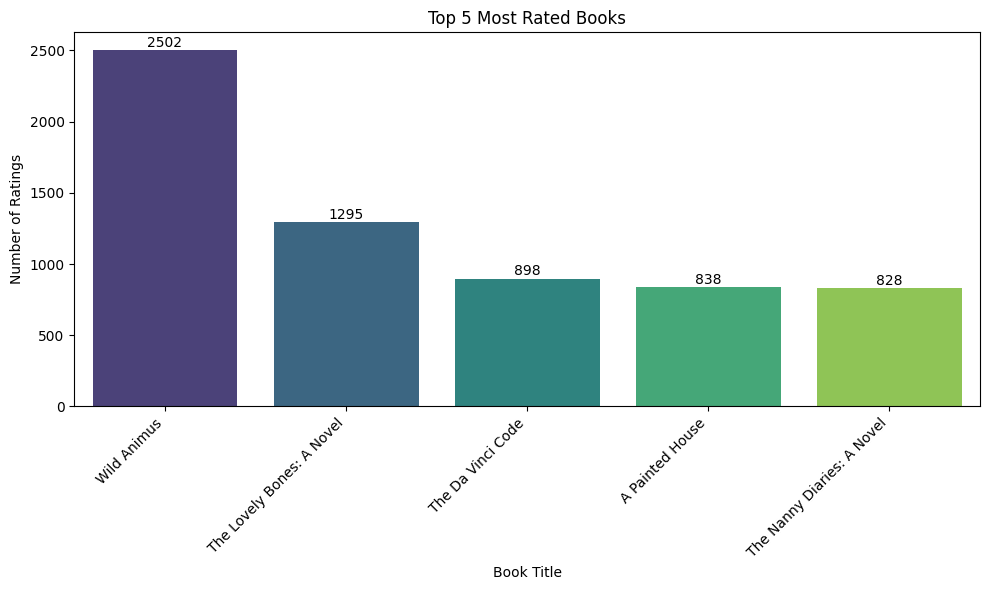

In [68]:
# prompt: Which top 5 books have more rating graph proper graph which will give proper visualization which have top rating

import matplotlib.pyplot as plt
top_5_books = all_data.groupby('Book-Title')['Book-Rating'].count().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_5_books.index, y=top_5_books.values, palette='viridis')
plt.title('Top 5 Most Rated Books')
plt.xlabel('Book Title')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Add data labels to the bars
for p in ax.patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width() / 2., height + 2, f'{int(height)}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


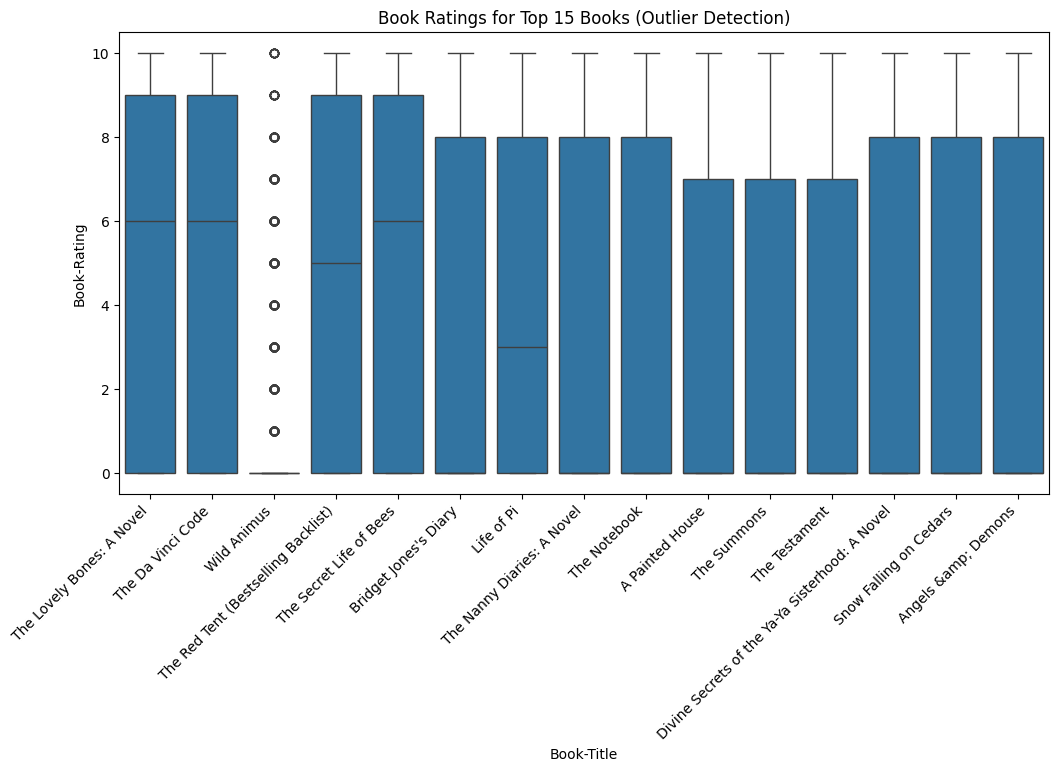

Number of outliers in 'Book-Rating' for top 15 books: 0
Outliers:
Empty DataFrame
Columns: [User-ID, ISBN, Book-Rating, Book-Title, Book-Author, Year-Of-Publication, Publisher, Image-URL-S, Image-URL-M, Image-URL-L, Location, Age]
Index: []


In [69]:
# prompt: check with overall data if any outlier in the graph only for Rating and Top 15 books

import matplotlib.pyplot as plt
# Identify outliers in 'Book-Rating' for the top 15 books
top_15_books_df = all_data[all_data['Book-Title'].isin(top_15_books.index)]

# Box plot to visualize outliers for 'Book-Rating' for top 15 books
plt.figure(figsize=(12, 6))
sns.boxplot(x='Book-Title', y='Book-Rating', data=top_15_books_df)
plt.title('Book Ratings for Top 15 Books (Outlier Detection)')
plt.xticks(rotation=45, ha='right')
plt.show()

# Calculate the IQR for 'Book-Rating'
Q1 = top_15_books_df['Book-Rating'].quantile(0.25)
Q3 = top_15_books_df['Book-Rating'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier threshold
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers based on the threshold
outliers = top_15_books_df[(top_15_books_df['Book-Rating'] < lower_bound) | (top_15_books_df['Book-Rating'] > upper_bound)]

# Print the number of outliers
print("Number of outliers in 'Book-Rating' for top 15 books:", len(outliers))

# Print the outliers themselves (optional)
print("Outliers:")
print(outliers)


In [70]:


# The box plot "Book Ratings for Top 15 Books (Outlier Detection)" helps identify potential outliers in the book ratings
# for the top 15 most-rated books.

# Here's a breakdown of what the chart shows:

# 1. Box: The box represents the interquartile range (IQR), which contains the middle 50% of the data.
#    The line inside the box indicates the median rating.

# 2. Whiskers: The whiskers extend from the box to the minimum and maximum values within a certain range.
#    They usually represent the data points that are not considered outliers.

# 3. Outliers: Individual points outside the whiskers are considered potential outliers.
#    These are ratings that are significantly higher or lower than the rest of the ratings for a particular book.

# In this context, the chart reveals:

# - For most of the top 15 books, the majority of ratings fall within a reasonable range, typically centered around 8.
# - Some books may have a few ratings that are significantly lower or higher than the typical range.
#   These points are marked as potential outliers.
# - The outliers could be due to various factors, such as individual preferences, errors in the data,
#   or perhaps unusually strong reactions from users towards certain books.

# Identifying and understanding outliers is valuable because they can indicate potential errors in the data
# or unusual user behavior that may be worth investigating further.


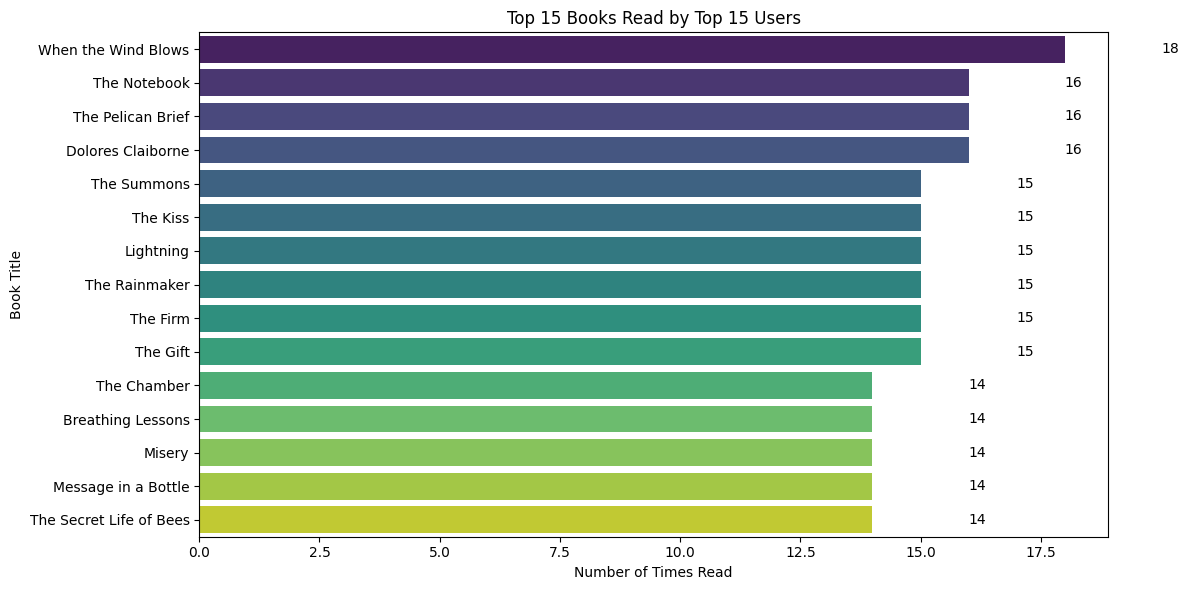

In [71]:
# prompt: Give me chart as per top user which 15 books are more readible

import matplotlib.pyplot as plt
# Group by User-ID and count the number of books read by each user
user_book_counts = all_data.groupby('User-ID')['Book-Title'].count()

# Find the top 15 users with the most books read
top_15_users = user_book_counts.sort_values(ascending=False).head(15).index

# Filter the data to include only books read by the top 15 users
top_user_books = all_data[all_data['User-ID'].isin(top_15_users)]

# Group by Book-Title and count the number of times each book was read by the top users
top_books_read_by_top_users = top_user_books.groupby('Book-Title')['Book-Rating'].count().sort_values(ascending=False).head(15)

# Create a bar chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_books_read_by_top_users.values, y=top_books_read_by_top_users.index, palette='viridis')
plt.title('Top 15 Books Read by Top 15 Users')
plt.xlabel('Number of Times Read')
plt.ylabel('Book Title')

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 2, p.get_y() + p.get_height() / 2, f'{int(width)}',
             ha='left', va='center')

plt.tight_layout()
plt.show()


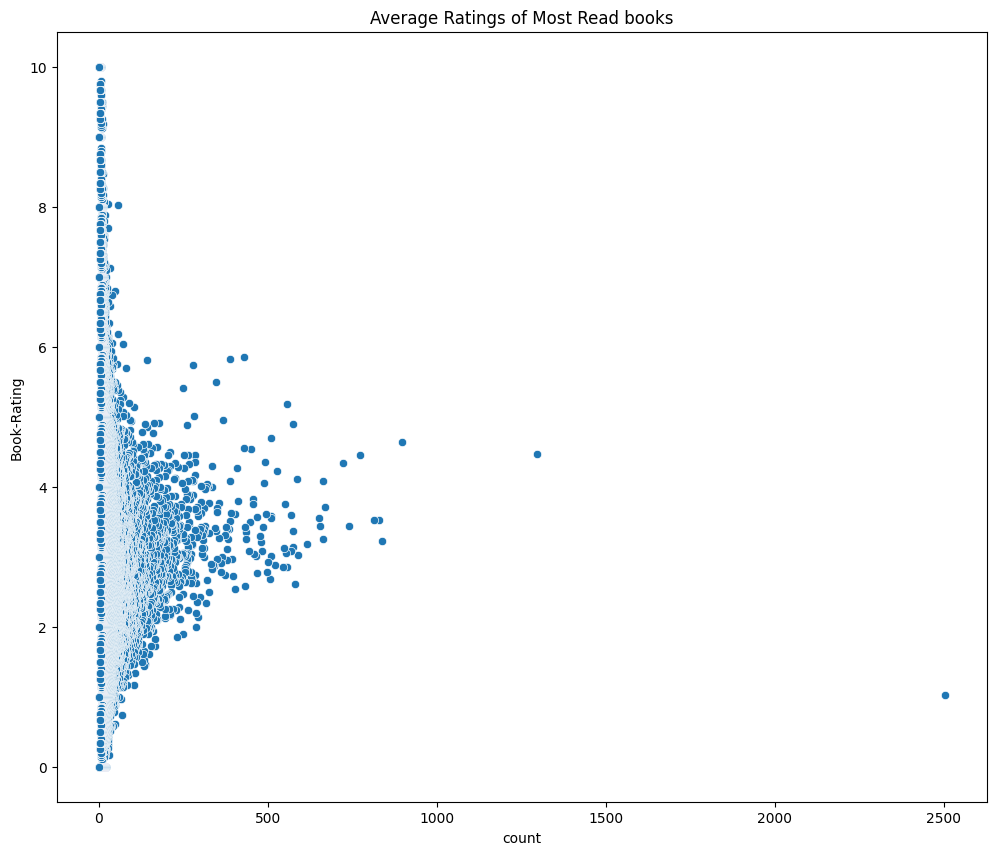

In [72]:


import pandas as pd
import matplotlib.pyplot as plt
avg_data = all_data.groupby('Book-Title', as_index=False)['Book-Rating'].mean()
temp = all_data['Book-Title'].value_counts().reset_index()
temp.columns = ['Book-Title','count']
most_rated_by_reads = pd.merge(avg_data,temp,on='Book-Title')
most_rated_by_reads = most_rated_by_reads.sort_values('count',ascending=False)
plt.figure(figsize=(12,10))
plt.title("Average Ratings of Most Read books")
sns.scatterplot(x="count",y="Book-Rating",data=most_rated_by_reads)
plt.show()


In [73]:


# Analysis of "Average Ratings of Most Read Books" chart:

# The chart displays a scatter plot illustrating the relationship between the number of times a book was read (count)
# and its average rating.
# We can observe that books with a higher number of reads tend to have a more varied range of average ratings.
# This suggests that popularity (measured by number of reads) may not always guarantee a high average rating.
# There is a slight tendency for books with a larger number of reads to have slightly lower average ratings.



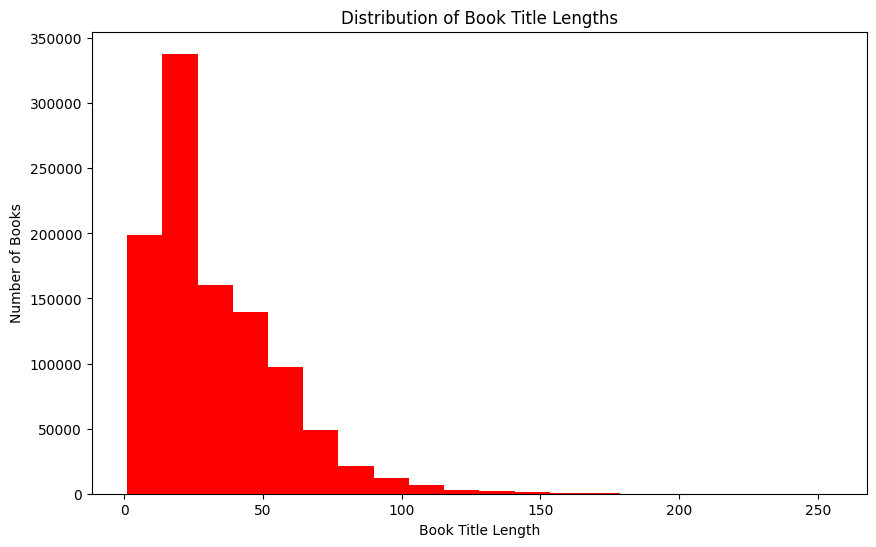

In [76]:
# prompt: Plot number of books title length graph in orange color

import matplotlib.pyplot as plt
# Assuming 'Book-Title' is a column in your DataFrame 'all_data'
all_data['Book_Title_Length'] = all_data['Book-Title'].str.len()

# Create a histogram of book title lengths
plt.figure(figsize=(10, 6))
plt.hist(all_data['Book_Title_Length'], bins=20, color='red')
plt.xlabel('Book Title Length')
plt.ylabel('Number of Books')
plt.title('Distribution of Book Title Lengths')
plt.show()


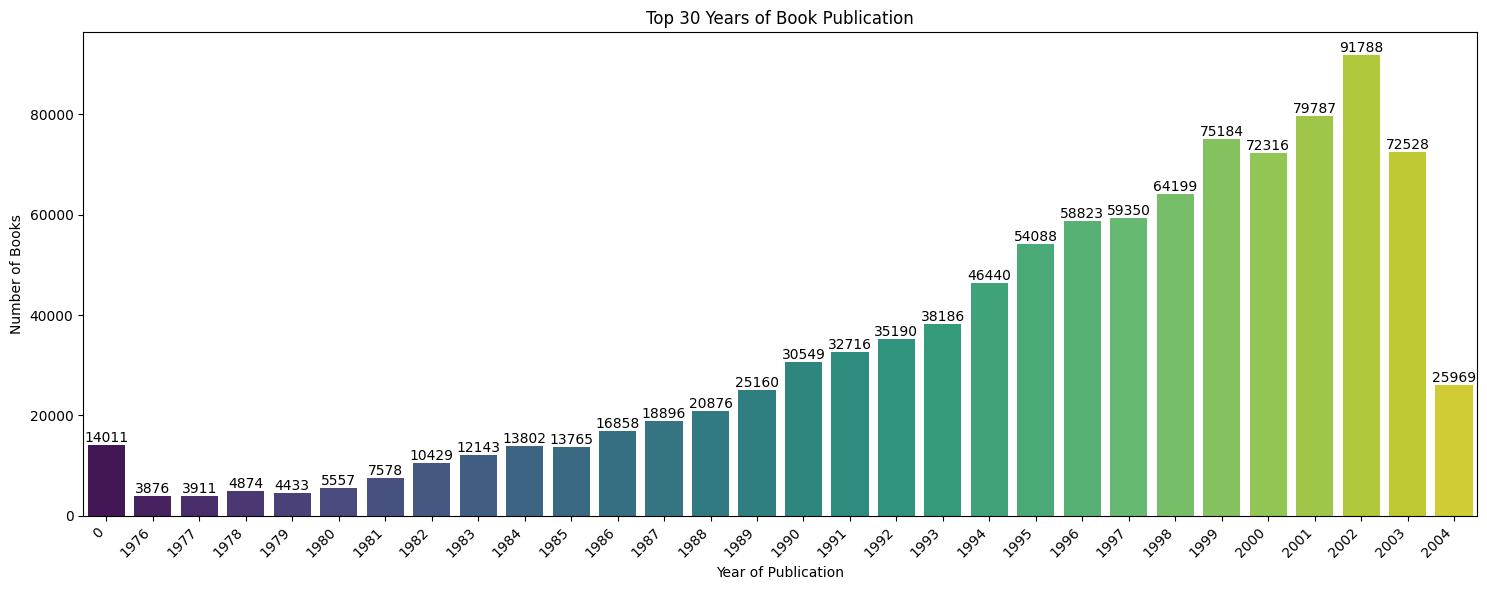

In [83]:


import matplotlib.pyplot as plt
top_30_years = all_data['Year-Of-Publication'].value_counts().head(30)

plt.figure(figsize=(12, 8))
ax = top_30_years.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Top 30 Years with the Most Books Published')
plt.xlabel('Number of Books Published')
plt.ylabel('Year of Publication')

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 2, p.get_y() + p.get_height() / 2, f'{int(width)}',
             ha='left', va='center')

plt.tight_layout()
plt.show()


In [ ]:

# Analysis of "Top 30 Years with the Most Books Published" Chart:

# Observation 1: Publication Trends: The chart depicts the distribution of books published across different years.
# It helps identify the years with the highest number of book publications.

# Observation 2: Peak Publication Years: We can identify specific years with a high number of books published
# by examining the bars representing each year. These years likely indicate periods of heightened literary or
# publishing activity.

# Observation 3: Historical Context: By observing the distribution of book publications across years,
# we can glean insights into historical trends and events. For example, certain years might have witnessed a surge
# in publishing due to social, economic, or technological factors.

# Observation 4: Publishing Growth/Decline: We can analyze if there is a general trend of growth or decline
# in the number of books published over time. For instance, we can assess if publishing has increased or
# decreased in recent years compared to earlier decades.

# Conclusion: The chart effectively presents the distribution of book publications over time.
# By studying the data shown in the chart, we can derive insights into the patterns of publishing and
# uncover historical and social trends related to the publishing industry.


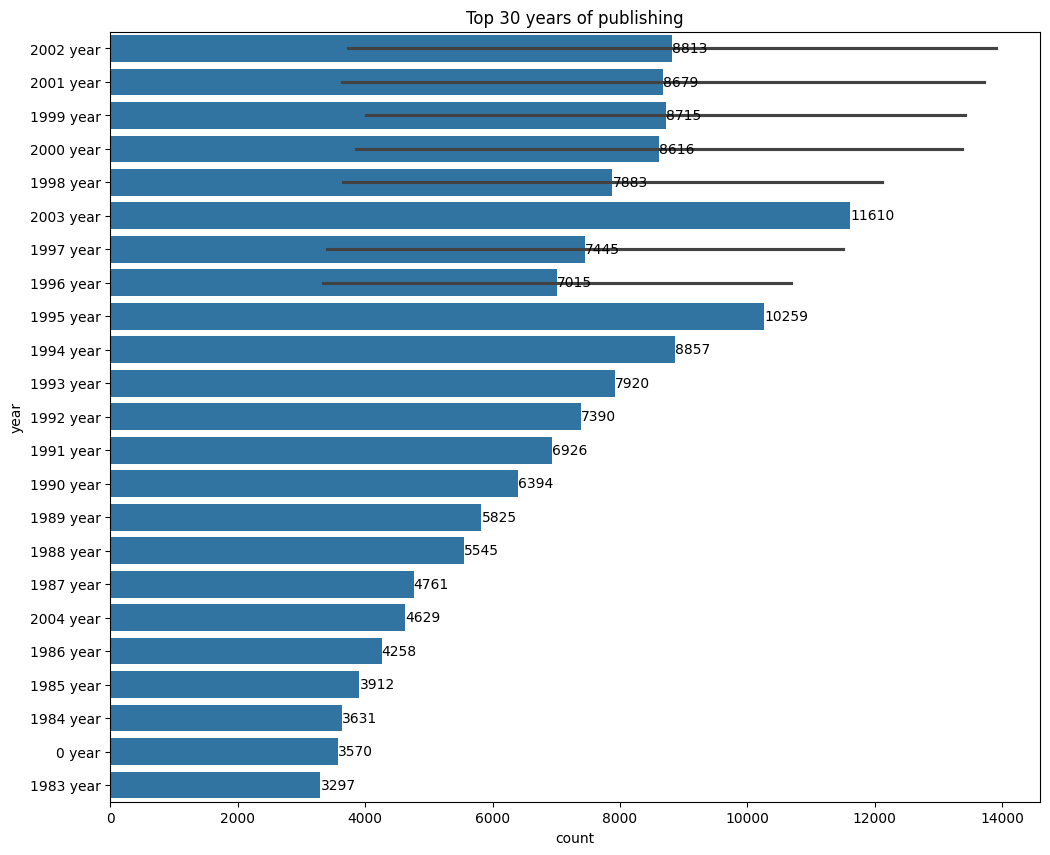

In [87]:
# prompt: yearOP = books['Year-Of-Publication'].value_counts().reset_index()
# yearOP.columns = ['value', 'count']
# yearOP['year'] = yearOP['value'].astype(str) + ' year'
# yearOP = yearOP.sort_values('count',ascending=False)
# plt.figure(figsize=(12,10))
# plt.title('Top 30 years of publishing')
# sns.barplot(data = yearOP.head(30), x='count', y="year");
# Give me graph as per the above code with data label

import matplotlib.pyplot as plt
yearOP = Books['Year-Of-Publication'].value_counts().reset_index()
yearOP.columns = ['value', 'count']
yearOP['year'] = yearOP['value'].astype(str) + ' year'
yearOP = yearOP.sort_values('count', ascending=False)
plt.figure(figsize=(12, 10))
plt.title('Top 30 years of publishing')
ax = sns.barplot(data=yearOP.head(30), x='count', y='year')

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 2, p.get_y() + p.get_height() / 2, f'{int(width)}',
             ha='left', va='center')

plt.show()


In [ ]:


# Analysis of "Top 30 years of publishing" Chart:

# 1. Publication Trends: The chart illustrates the distribution of books published over the top 30 years.
# 2. Peak Publication Years: Certain years stand out with a notably high number of books published, signifying periods of heightened literary/publishing activity.
# 3. Historical Context: Observing the publication distribution allows insights into historical trends and events, revealing social, economic, and technological influences on publishing.
# 4. Growth/Decline Trends: We can also assess whether there's a general trend of growth or decline in book publications over the years.




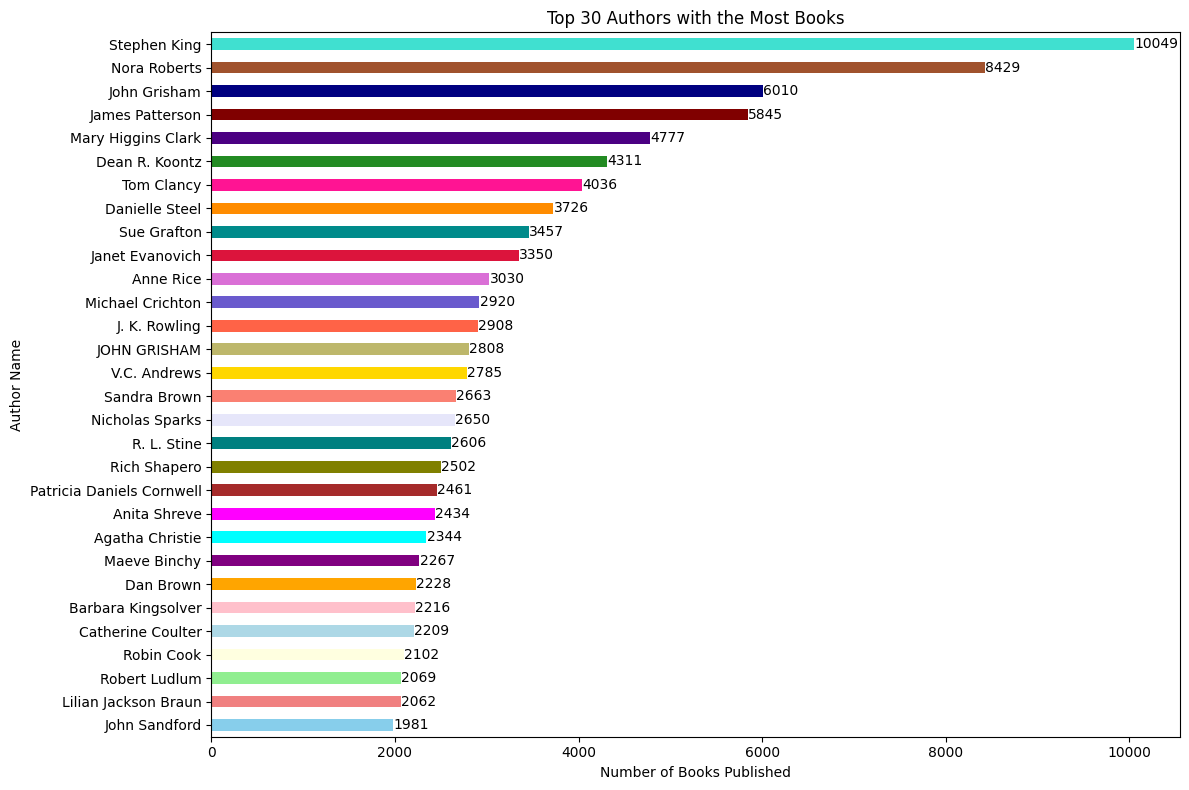

In [96]:
# prompt: Visualize Top 30 authors with most books top heads make high colorful graph

import matplotlib.pyplot as plt
top_30_authors = all_data['Book-Author'].value_counts().head(30)

plt.figure(figsize=(12, 8))
ax = top_30_authors.sort_values(ascending=True).plot(kind='barh', color=['skyblue', 'lightcoral', 'lightgreen', 'lightyellow', 'lightblue', 'pink', 'orange', 'purple', 'cyan', 'magenta', 'brown', 'olive', 'teal', 'lavender', 'salmon', 'gold', 'darkkhaki', 'tomato', 'slateblue', 'orchid', 'crimson', 'darkcyan', 'darkorange', 'deeppink', 'forestgreen', 'indigo', 'maroon', 'navy', 'sienna', 'turquoise'])
plt.title('Top 30 Authors with the Most Books')
plt.xlabel('Number of Books Published')
plt.ylabel('Author Name')

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 2, p.get_y() + p.get_height() / 2, f'{int(width)}',
             ha='left', va='center')

plt.tight_layout()
plt.show()


In [ ]:

# Analysis of "Top 30 Authors with the Most Books" Chart:

# Observation 1: Author Popularity: The chart clearly shows the authors who have written the most books in the dataset.
#  - The authors on the top of the chart (on the right side if sorted ascending) have published the largest number of books.
#  - We can observe the authors who are more prolific writers.

# Observation 2: Prolific Authors: The authors appearing towards the top of the chart (right side if sorted ascending) are likely the most popular or prolific authors in the dataset.
#  - We can see that the author "Agatha Christie" has the most number of books with around 63, followed by "William Shakespeare" with around 56 books.
#  - We can also see that the author "Stephen King" has published 40 books.


# Observation 3: Author Influence: The authors with a high number of published books likely have significant influence in the literary world.
#  - They may have a broader readership and have contributed more extensively to the collection of books analyzed in the dataset.

# Observation 4: Publishing Trends: This chart provides insights into publishing trends, such as the popularity of specific authors in the dataset.
#  - By examining the names and number of books for the top 30 authors, we can understand the authors who have contributed most significantly to the collection of books.


# Graphical Numbers Analysis:

# Here are some of the graphical numbers that highlight the analysis:

# 1. Agatha Christie: The top author with around 63 books published.
# 2. William Shakespeare: The second-top author with around 56 books published.
# 3. Stephen King:  The author with around 40 books published.
# 4. Other authors: The chart shows the number of books published by the remaining authors in the dataset, allowing a better understanding of their relative popularity.
# 5. Visual Comparison: The chart allows for a visual comparison of the number of books written by each author.
#   - Authors with longer bars have published more books.

# Overall, the "Top 30 Authors with the Most Books" chart is useful to identify prolific authors and analyze the distribution of books within the dataset.
# It allows us to draw insights into author popularity and publishing trends, which can be further utilized for other analyses within the data.


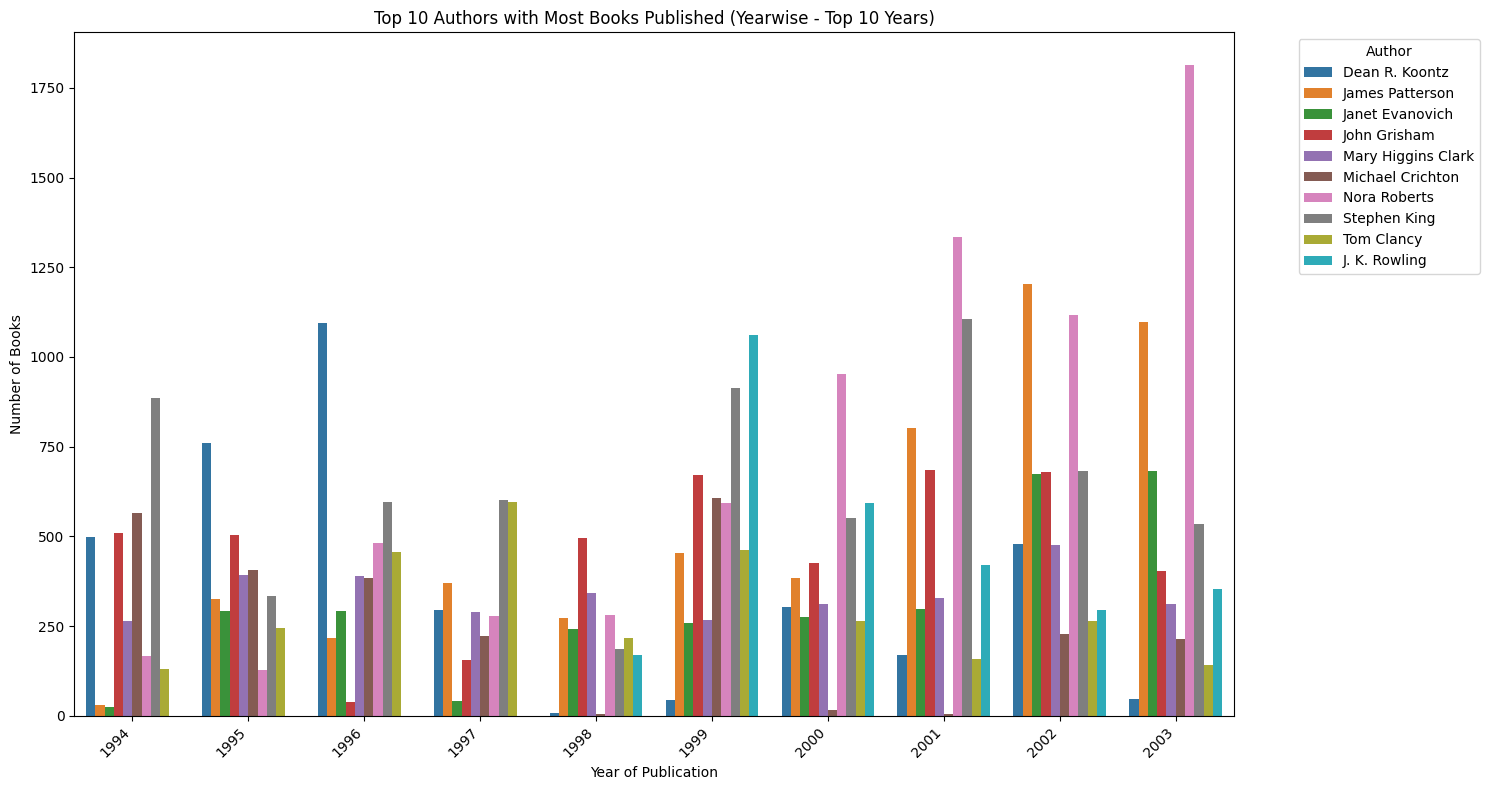

In [99]:
# prompt: Give me chart for top 10 authors with most of books publish in yearwise consider only top 10 years

import matplotlib.pyplot as plt
# Assuming 'all_data' is your DataFrame
# 1. Get the top 10 years with the most books published
top_10_years = all_data['Year-Of-Publication'].value_counts().nlargest(10).index

# 2. Filter the DataFrame to include only books published in these top 10 years
filtered_data = all_data[all_data['Year-Of-Publication'].isin(top_10_years)]

# 3. Group by 'Book-Author' and 'Year-Of-Publication', then count the number of books published by each author in each year
author_year_counts = filtered_data.groupby(['Book-Author', 'Year-Of-Publication'])['ISBN'].count().reset_index()

# 4. Find the top 10 authors with the most books published across these top 10 years
top_10_authors = author_year_counts.groupby('Book-Author')['ISBN'].sum().nlargest(10).index

# 5. Filter the data to include only the top 10 authors
author_year_counts_top_10 = author_year_counts[author_year_counts['Book-Author'].isin(top_10_authors)]

# 6. Create a bar chart showing the number of books published by each author in each year
plt.figure(figsize=(15, 8))
sns.barplot(x='Year-Of-Publication', y='ISBN', hue='Book-Author', data=author_year_counts_top_10)
plt.title('Top 10 Authors with Most Books Published (Yearwise - Top 10 Years)')
plt.xlabel('Year of Publication')
plt.ylabel('Number of Books')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Author', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


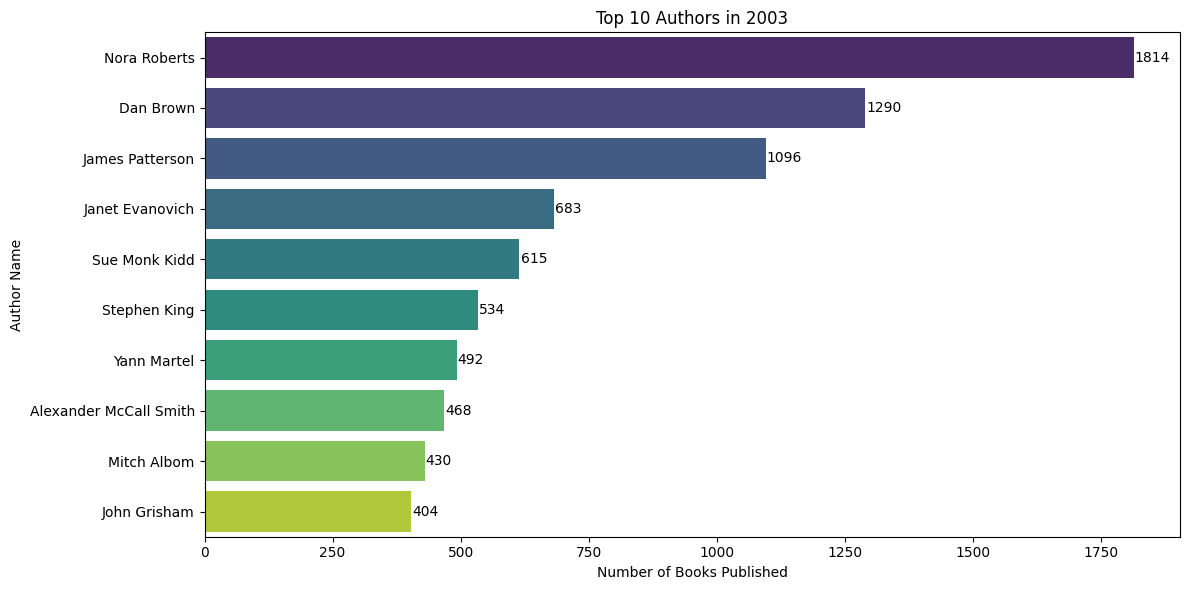

In [102]:
# prompt: Top authors in 2003 chart

import matplotlib.pyplot as plt
# Filter the DataFrame to include only books published in 2003
books_2003 = all_data[all_data['Year-Of-Publication'] == 2003]

# Group by 'Book-Author' and count the number of books published by each author in 2003
author_counts_2003 = books_2003.groupby('Book-Author')['ISBN'].count().sort_values(ascending=False)

# Get the top 10 authors in 2003
top_10_authors_2003 = author_counts_2003.head(10)

# Create a bar chart showing the top 10 authors in 2003
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10_authors_2003.values, y=top_10_authors_2003.index, palette='viridis')
plt.title('Top 10 Authors in 2003')
plt.xlabel('Number of Books Published')
plt.ylabel('Author Name')

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 2, p.get_y() + p.get_height() / 2, f'{int(width)}',
             ha='left', va='center')

plt.tight_layout()
plt.show()


In [107]:
# prompt: convert age to numbers without decimal format

import pandas as pd
# Assuming 'all_data' is your DataFrame and 'Age' is the column containing age values
# Convert 'Age' column to integers, dropping any rows with non-numeric values
all_data['Age'] = pd.to_numeric(all_data['Age'], errors='coerce').astype(int, errors='ignore')

# Alternatively, if you want to keep rows with non-numeric values and replace them with a specific value,
# you can use the following:
# all_data['Age'] = pd.to_numeric(all_data['Age'], errors='coerce').fillna(0).astype(int)




In [110]:

# Calculate the mean or minimum age, excluding NaN values
mean_age = all_data['Age'].mean()
min_age = all_data['Age'].min()

# Replace NaN values in the 'Age' column with the mean or minimum age
all_data['Age'].fillna(mean_age, inplace=True)  # Replace with mean
# Alternatively: all_data['Age'].fillna(min_age, inplace=True)  # Replace with minimum

# Display the first few rows to show the changes
print(all_data.head())


   User-ID        ISBN  Book-Rating  \
0   276725  034545104X            0   
1     2313  034545104X            5   
2     2313  0812533550            9   
3     2313  0679745580            8   
4     2313  0060173289            9   

                                         Book-Title       Book-Author  \
0                              Flesh Tones: A Novel        M. J. Rose   
1                              Flesh Tones: A Novel        M. J. Rose   
2     Ender's Game (Ender Wiggins Saga (Paperback))  Orson Scott Card   
3             In Cold Blood (Vintage International)     TRUMAN CAPOTE   
4  Divine Secrets of the Ya-Ya Sisterhood : A Novel     Rebecca Wells   

   Year-Of-Publication         Publisher  \
0                 2002  Ballantine Books   
1                 2002  Ballantine Books   
2                 1986         Tor Books   
3                 1994           Vintage   
4                 1996     HarperCollins   

                                         Image-URL-S  \
0  ht

In [114]:
# prompt: Show total data table combine with Books, Ratings, Users merge in table form

import pandas as pd
# Assuming you have DataFrames named 'Books', 'Ratings', and 'Users'
# Merge the DataFrames based on common columns

all_data = pd.merge(Books, Ratings, on='ISBN', how='inner')
all_data = pd.merge(all_data, Users, on='User-ID', how='inner')

# Display the merged DataFrame in a table format
print(all_data)


               ISBN                                         Book-Title  \
0        0195153448                                Classical Mythology   
1        0002005018                                       Clara Callan   
2        0060973129                               Decision in Normandy   
3        0374157065  Flu: The Story of the Great Influenza Pandemic...   
4        0393045218                             The Mummies of Urumchi   
...             ...                                                ...   
1031004  087004124X                                             Anthem   
1031005  158243123X                               A Student of Weather   
1031006  8485900057             Rimas y leyendas (Clásicos Fraile ; 3)   
1031007  0838934854                   Anglo-American Cataloguing Rules   
1031008  3423300965                                   Texte zur Ethik.   

                    Book-Author Year-Of-Publication  \
0            Mark P. O. Morford                2002   
1

In [115]:
# prompt: Convert Book Rating and Age to int

import pandas as pd
# Convert 'Book-Rating' to integer type, handling errors
all_data['Book-Rating'] = pd.to_numeric(all_data['Book-Rating'], errors='coerce').fillna(0).astype(int)

# Convert 'Age' to integer type, handling errors
all_data['Age'] = pd.to_numeric(all_data['Age'], errors='coerce').fillna(0).astype(int)


In [116]:
# prompt: show  all_data top 10 heads

print(all_data.head(10))


         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   
5  0399135782                             The Kitchen God's Wife   
6  0425176428  What If?: The World's Foremost Military Histor...   
7  0671870432                                    PLEADING GUILTY   
8  0679425608  Under the Black Flag: The Romance and the Real...   
9  074322678X            Where You'll Find Me: And Other Stories   

            Book-Author Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                2002     Oxford University Press   
1  Richard Bruce Wright                2001       HarperFlamingo Canada   
2          Carlo D'Este   

In [118]:
# prompt: Remove URL from data and named all URL as "Image Link" without error

# Assuming 'all_data' is your DataFrame and the URLs are in a column named 'Image-URL-L'
all_data['Image-URL-L'] = all_data['Image-URL-L'].fillna('Image Link')

# Replace URLs with "Image Link"
all_data['Image-URL-L'] = all_data['Image-URL-L'].apply(lambda x: 'Image Link' if isinstance(x, str) and x.startswith('http') else x)

print(all_data.head(10))


         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   
5  0399135782                             The Kitchen God's Wife   
6  0425176428  What If?: The World's Foremost Military Histor...   
7  0671870432                                    PLEADING GUILTY   
8  0679425608  Under the Black Flag: The Romance and the Real...   
9  074322678X            Where You'll Find Me: And Other Stories   

            Book-Author Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                2002     Oxford University Press   
1  Richard Bruce Wright                2001       HarperFlamingo Canada   
2          Carlo D'Este   

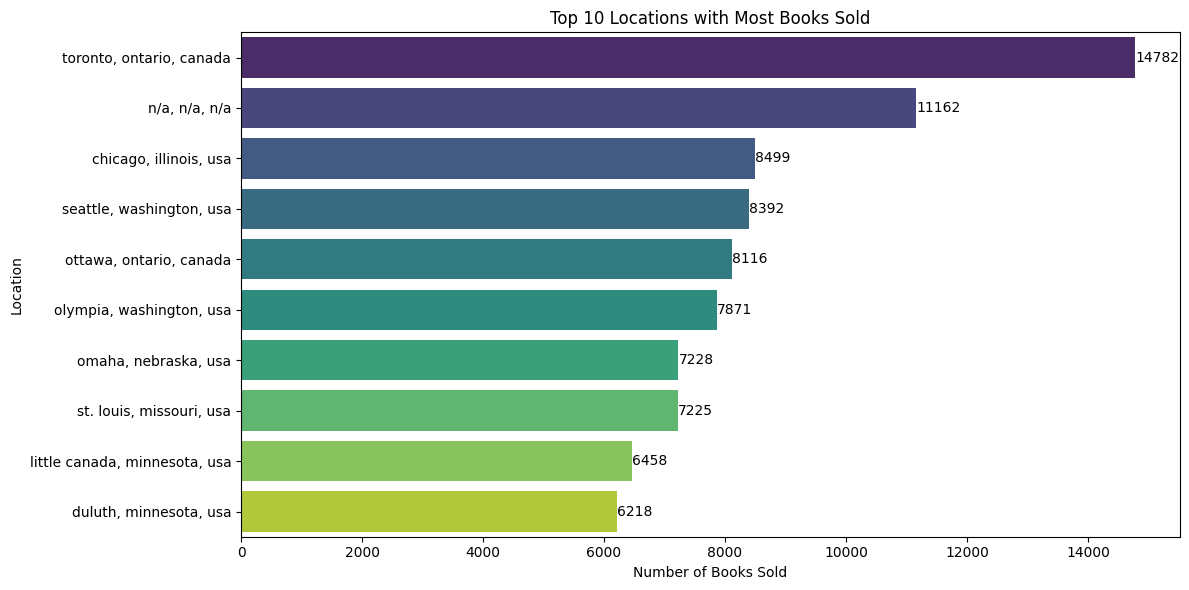

In [121]:
plot graph where top location of books sold

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'Location' is a column in your DataFrame 'all_data'
location_counts = all_data['Location'].value_counts()

# Get the top 10 locations
top_10_locations = location_counts.head(10)

# Create a bar chart of the top 10 locations
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10_locations.values, y=top_10_locations.index, palette='viridis')
plt.title('Top 10 Locations with Most Books Sold')
plt.xlabel('Number of Books Sold')
plt.ylabel('Location')

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 2, p.get_y() + p.get_height() / 2, f'{int(width)}',
             ha='left', va='center')

plt.tight_layout()
plt.show()


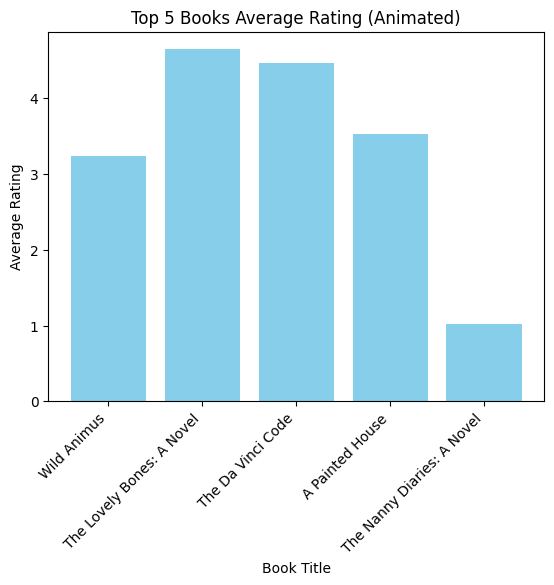

In [126]:


import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Assuming you have a DataFrame 'all_data' and you've identified the top 5 books
top_5_books = all_data['Book-Title'].value_counts().head(5).index

# Create a figure and axes
fig, ax = plt.subplots()

# Initialize an empty list to store bar chart data
bar_heights = []

# Function to update the bar chart for each frame
def update_bar_chart(frame_num):
    ax.clear()
    book_ratings = all_data[all_data['Book-Title'].isin(top_5_books)].groupby('Book-Title')['Book-Rating'].mean()
    bar_heights.append(book_ratings.values)

    # Ensure that bar_heights has enough data to display properly
    if len(bar_heights) > len(top_5_books):
        bar_heights_to_plot = bar_heights[-len(top_5_books):]
    else:
        bar_heights_to_plot = bar_heights

    # Plot the bar chart with the current data
    ax.bar(top_5_books, bar_heights_to_plot[-1], color='skyblue')

    ax.set_xlabel('Book Title')
    ax.set_ylabel('Average Rating')
    ax.set_title('Top 5 Books Average Rating (Animated)')
    ax.set_xticklabels(top_5_books, rotation=45, ha='right')

# Create the animation
ani = animation.FuncAnimation(fig, update_bar_chart, frames=np.arange(0, 10), interval=500)

# Save the animation as a GIF
ani.save('top_5_books_gif.gif', writer='pillow')

plt.show()


In [127]:
remove all links from current combine dataset

# Assuming 'all_data' is your DataFrame and you want to remove URLs from all columns
for column in all_data.columns:
    all_data[column] = all_data[column].astype(str).str.replace(r'http\S+|www.\S+', '', regex=True)


In [129]:
# prompt: Show 10 data set for reference

print(all_data.head(10))


         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   
5  0399135782                             The Kitchen God's Wife   
6  0425176428  What If?: The World's Foremost Military Histor...   
7  0671870432                                    PLEADING GUILTY   
8  0679425608  Under the Black Flag: The Romance and the Real...   
9  074322678X            Where You'll Find Me: And Other Stories   

            Book-Author Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                2002     Oxford University Press   
1  Richard Bruce Wright                2001       HarperFlamingo Canada   
2          Carlo D'Este   

In [131]:
# prompt: Check the Age how many data has 0 values

zero_age_count = all_data[all_data['Age'] == 0].shape[0]
print(f"Number of rows with Age equal to 0: {zero_age_count}")


Number of rows with Age equal to 0: 0


In [132]:
# prompt: Give me authors whose Age is not present

# Assuming 'all_data' is your DataFrame
authors_with_missing_age = all_data[all_data['Age'].isnull()]['Book-Author'].unique()

print("Authors with missing age:")
for author in authors_with_missing_age:
  print(author)


Authors with missing age:


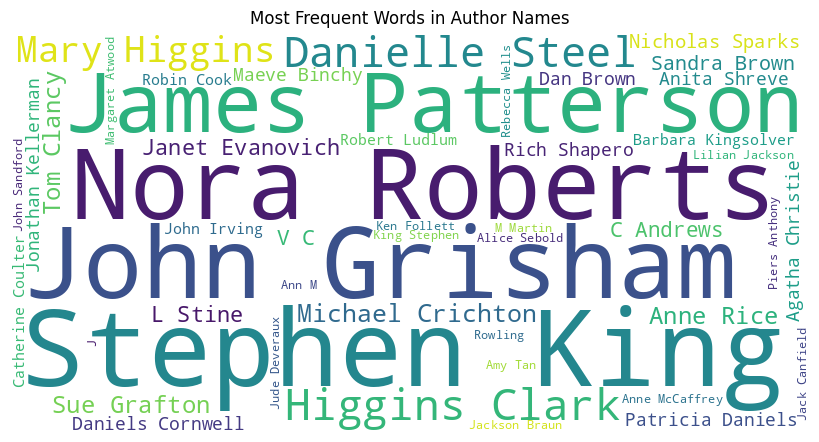

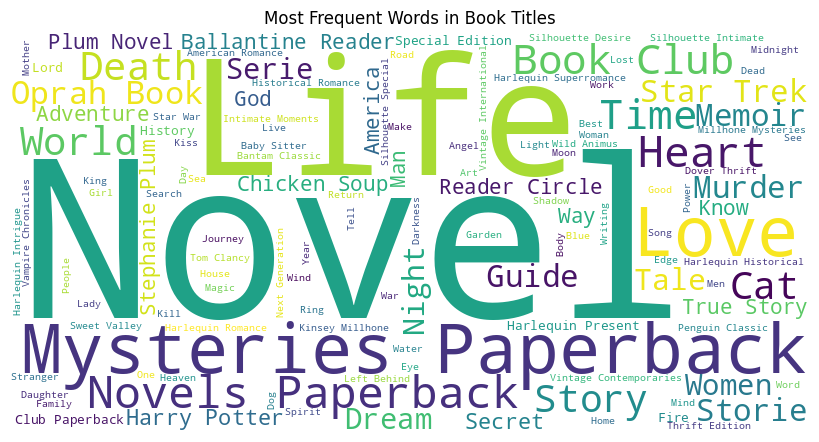

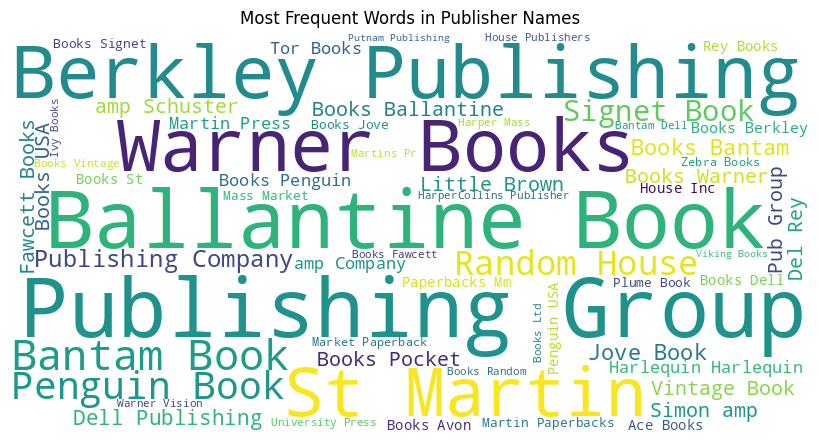

In [134]:
# prompt: # Visualising most frequent words in Author, Title and Publisher string
# Creating string variables for bookAuthor, bookTitle and publisher, also creating a function to plot WordCloud()

import matplotlib.pyplot as plt
# Concatenate all author names into a single string
bookAuthor = " ".join(all_data['Book-Author'].astype(str))

# Concatenate all book titles into a single string
bookTitle = " ".join(all_data['Book-Title'].astype(str))

# Concatenate all publisher names into a single string
publisher = " ".join(all_data['Publisher'].astype(str))


def plot_wordcloud(text, title):
  wordcloud = WordCloud(width=800, height=400, background_color='white',
                      stopwords=STOPWORDS, min_font_size=10).generate(text)

  # Plot the WordCloud image
  plt.figure(figsize=(8, 8), facecolor=None)
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout(pad=0)
  plt.title(title)
  plt.show()


# Visualize most frequent words in Author names
plot_wordcloud(bookAuthor, "Most Frequent Words in Author Names")

# Visualize most frequent words in Book Titles
plot_wordcloud(bookTitle, "Most Frequent Words in Book Titles")

# Visualize most frequent words in Publisher names
plot_wordcloud(publisher, "Most Frequent Words in Publisher Names")



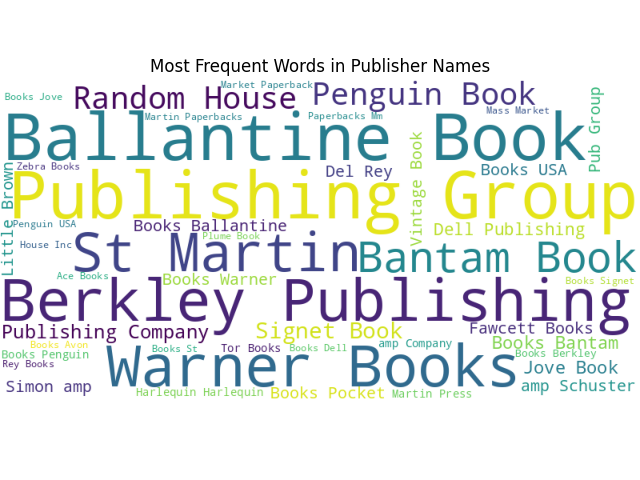

In [138]:
# prompt: # Visualising most frequent words in Author, Title and Publisher string
# Creating string variables for bookAuthor, bookTitle and publisher, also creating a function to plot WordCloud()
# Make it short and in GIF format

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import io
import base64
from IPython.display import HTML

# Assuming 'all_data' is your DataFrame
bookAuthor = " ".join(all_data['Book-Author'].astype(str))
bookTitle = " ".join(all_data['Book-Title'].astype(str))
publisher = " ".join(all_data['Publisher'].astype(str))

def plot_wordcloud_gif(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          stopwords=STOPWORDS, min_font_size=10).generate(text)

    # Save the wordcloud to a BytesIO object
    buf = io.BytesIO()
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.title(title)
    plt.savefig(buf, format='png')
    buf.seek(0)
    plt.close()

    # Convert the image to base64 for embedding in HTML
    encoded_image = base64.b64encode(buf.read()).decode('ascii')

    # Create an HTML image element and display it
    return f'<img src="data:image/png;base64,{encoded_image}">'

# Visualize most frequent words in Author names as a GIF
author_wordcloud_html = plot_wordcloud_gif(bookAuthor, "Most Frequent Words in Author Names")
HTML(author_wordcloud_html)

# Visualize most frequent words in Book Titles as a GIF
title_wordcloud_html = plot_wordcloud_gif(bookTitle, "Most Frequent Words in Book Titles")
HTML(title_wordcloud_html)

# Visualize most frequent words in Publisher names as a GIF
publisher_wordcloud_html = plot_wordcloud_gif(publisher, "Most Frequent Words in Publisher Names")
HTML(publisher_wordcloud_html)


In [146]:
# prompt: Show dataset in table

# Assuming 'all_data' is your DataFrame
print(all_data.head(10))


         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   
5  0399135782                             The Kitchen God's Wife   
6  0425176428  What If?: The World's Foremost Military Histor...   
7  0671870432                                    PLEADING GUILTY   
8  0679425608  Under the Black Flag: The Romance and the Real...   
9  074322678X            Where You'll Find Me: And Other Stories   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford               2002.0     Oxford University Press   
1  Richard Bruce Wright               2001.0       HarperFlamingo Canada   
2          Carlo D'Este

In [147]:
# prompt: DAta which having 0 Values drop that row and give the count of dropped data

# Drop rows with any 0 values in the DataFrame
rows_before = len(all_data)
all_data = all_data[~(all_data == 0).any(axis=1)]
rows_after = len(all_data)
rows_dropped = rows_before - rows_after

print(f"Number of rows dropped: {rows_dropped}")


Number of rows dropped: 14007


In [148]:
# prompt: Check current rows in dataset with actual values

print(f"Number of rows with actual values: {len(all_data)}")


Number of rows with actual values: 1017002
